# Notebook 10 — Bayesian Network: Structure, CPTs & Ablation

**Purpose (read-only historical analysis):**  
This notebook documents why the Bayesian Network (Hybrid v1) failed as the primary reasoner
and was replaced by Random Forest (Hybrid v2). It is **not** part of the live pipeline.

All BN cells are frozen at the historical F1 = 0.159 result.

In [11]:
# ── Cell 1: Path bootstrap ──────────────────────────────────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').exists()), None
)
assert PROJECT_ROOT, 'Could not locate project root containing src/'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: /Users/subhammahapatra/Downloads/agastya


In [12]:
# ── Cell 2: Imports ──────────────────────────────────────────────────────────
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('Imports OK')

Imports OK


## 1. BN Architecture — What Was Built

The Bayesian Network was designed with 5 evidence nodes (one per clause category)
and 1 risk node. The Phase 2 → Phase 3 adapter mapped all 41 CUAD labels down
to these 5 binary nodes.

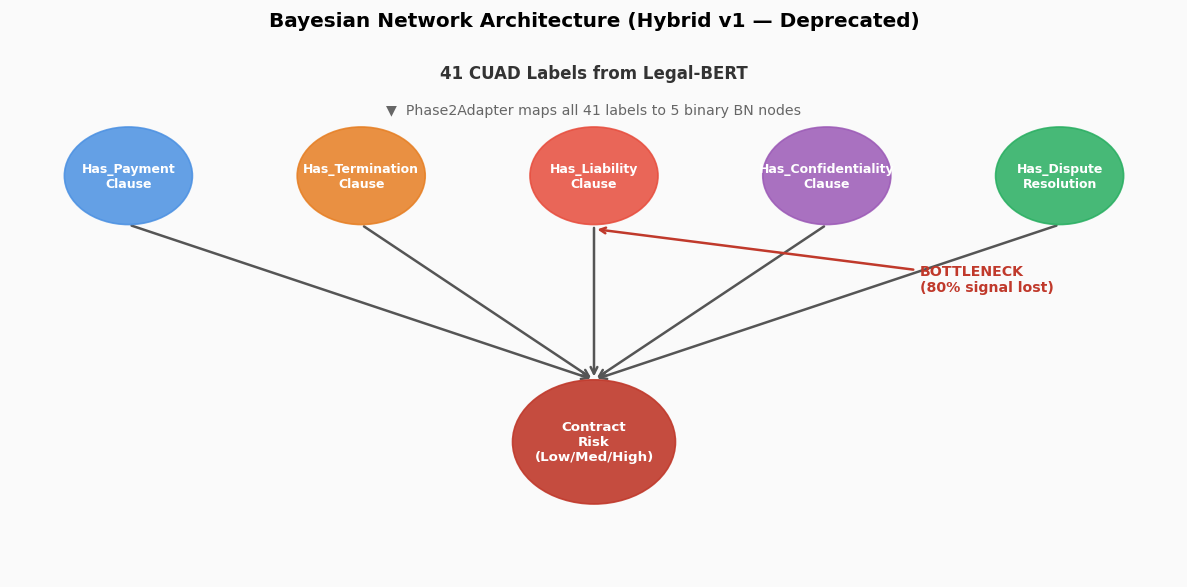

In [13]:
# ── Cell 3: BN node structure diagram ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('#fafafa')

# Evidence nodes
evidence_nodes = [
    (1.0, 4.5, 'Has_Payment\nClause', '#4a90e2'),
    (3.0, 4.5, 'Has_Termination\nClause', '#e67e22'),
    (5.0, 4.5, 'Has_Liability\nClause', '#e74c3c'),
    (7.0, 4.5, 'Has_Confidentiality\nClause', '#9b59b6'),
    (9.0, 4.5, 'Has_Dispute\nResolution', '#27ae60'),
]

for x, y, label, color in evidence_nodes:
    circle = plt.Circle((x, y), 0.55, color=color, alpha=0.85, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', fontsize=7.5, color='white',
            fontweight='bold', zorder=4)
    ax.annotate('', xy=(5.0, 2.2), xytext=(x, y - 0.55),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5), zorder=2)

# Risk node
risk_circle = plt.Circle((5.0, 1.5), 0.7, color='#c0392b', alpha=0.9, zorder=3)
ax.add_patch(risk_circle)
ax.text(5.0, 1.5, 'Contract\nRisk\n(Low/Med/High)', ha='center', va='center',
        fontsize=8, color='white', fontweight='bold', zorder=4)

# Labels for BERT
ax.text(5, 5.6, '41 CUAD Labels from Legal-BERT', ha='center', fontsize=10,
        fontweight='bold', color='#333')
ax.text(5, 5.2, '▼  Phase2Adapter maps all 41 labels to 5 binary BN nodes',
        ha='center', fontsize=8.5, color='#666')

# Bottleneck annotation
ax.annotate('BOTTLENECK\n(80% signal lost)',
            xy=(5, 3.9), xytext=(7.8, 3.2),
            fontsize=8.5, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

ax.set_title('Bayesian Network Architecture (Hybrid v1 — Deprecated)', fontsize=12,
             fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/bn_architecture.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 2. Root Cause Analysis — Why F1 = 0.159

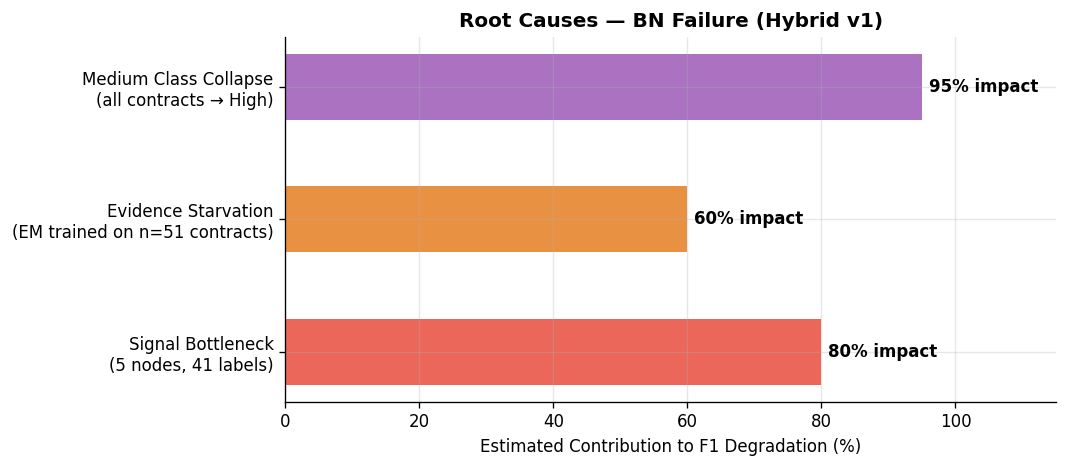

In [14]:
# ── Cell 4: Root cause bar chart ─────────────────────────────────────────────
causes = [
    ('Signal Bottleneck\n(5 nodes, 41 labels)', 80),
    ('Evidence Starvation\n(EM trained on n=51 contracts)', 60),
    ('Medium Class Collapse\n(all contracts → High)', 95),
]

fig, ax = plt.subplots(figsize=(9, 4))
labels_  = [c[0] for c in causes]
severity = [c[1] for c in causes]
colors   = ['#e74c3c', '#e67e22', '#9b59b6']
bars = ax.barh(labels_, severity, color=colors, height=0.5, alpha=0.85)

for bar, val in zip(bars, severity):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val}% impact', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Estimated Contribution to F1 Degradation (%)', fontsize=10)
ax.set_title('Root Causes — BN Failure (Hybrid v1)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/bn_failure_root_causes.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 3. CPT Structure — Conditional Probability Tables

The BN used hand-specified CPTs. Below shows the prior CPT for the Risk node under the seed model.

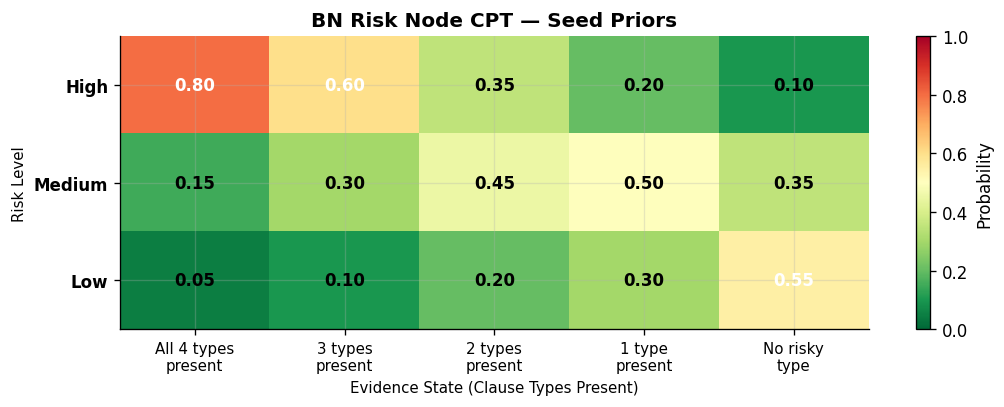

In [15]:
# ── Cell 5: CPT heatmap (seed model priors) ──────────────────────────────────
# These are the seed CPT values from bayesian/cpt_definitions.py.
# Rows = risk states, Cols = clause-type combinations (simplified)
cpt_data = np.array([
    [0.80, 0.60, 0.35, 0.20, 0.10],  # High risk
    [0.15, 0.30, 0.45, 0.50, 0.35],  # Medium risk
    [0.05, 0.10, 0.20, 0.30, 0.55],  # Low risk
])
col_labels = [
    'All 4 types\npresent',
    '3 types\npresent',
    '2 types\npresent',
    '1 type\npresent',
    'No risky\ntype',
]
row_labels = ['High', 'Medium', 'Low']

fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(cpt_data, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Probability')

ax.set_xticks(range(len(col_labels)))
ax.set_yticks(range(len(row_labels)))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticklabels(row_labels, fontsize=10, fontweight='bold')

for i in range(cpt_data.shape[0]):
    for j in range(cpt_data.shape[1]):
        ax.text(j, i, f'{cpt_data[i,j]:.2f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if cpt_data[i,j] > 0.5 else 'black')

ax.set_title('BN Risk Node CPT — Seed Priors', fontsize=12, fontweight='bold')
ax.set_xlabel('Evidence State (Clause Types Present)', fontsize=9)
ax.set_ylabel('Risk Level', fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/bn_cpt_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 4. BN vs RF — Performance Comparison

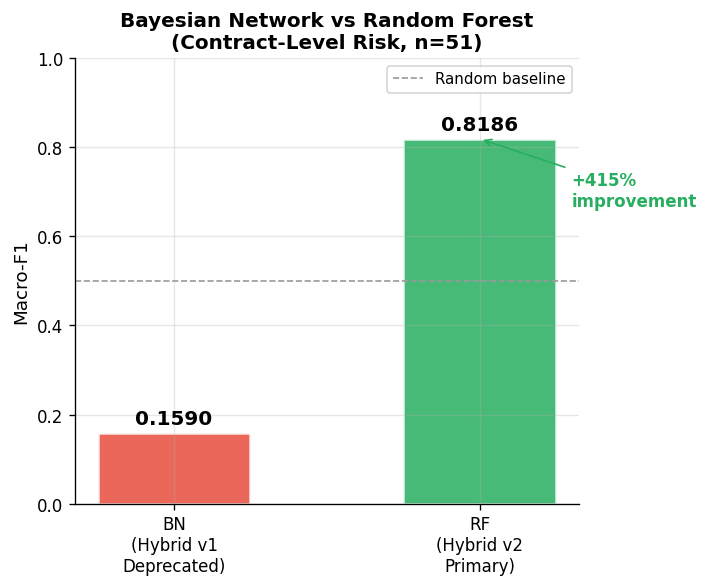

BN Macro-F1:  0.1590
RF Macro-F1:  0.8186
Improvement:  414.9%


In [16]:
# ── Cell 6: BN vs RF comparison bar chart ────────────────────────────────────
# Historical BN result is pinned from phase_progression_summary.csv.
# RF result is loaded from hybrid_eval.json (live artifact).
progression_path = PROJECT_ROOT / 'reports/phase3/phase_progression_summary.csv'
hybrid_path      = PROJECT_ROOT / 'reports/phase3/hybrid_eval.json'

prog_df = pd.read_csv(progression_path)
bn_row  = prog_df[prog_df['MetricStatus'] == 'deprecated_bn'].iloc[0]
bn_f1   = float(bn_row['Macro-F1'])

with open(hybrid_path) as f:
    hybrid = json.load(f)
rf_f1 = float(hybrid['macro_f1'])

configs = ['BN\n(Hybrid v1\nDeprecated)', 'RF\n(Hybrid v2\nPrimary)']
f1s     = [bn_f1, rf_f1]
colors  = ['#e74c3c', '#27ae60']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(configs, f1s, color=colors, alpha=0.85, width=0.5,
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12,
            fontweight='bold')

ax.axhline(0.5, color='#999', linestyle='--', linewidth=1, label='Random baseline')
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title('Bayesian Network vs Random Forest\n(Contract-Level Risk, n=51)', 
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9)

improvement = ((rf_f1 - bn_f1) / bn_f1) * 100
ax.annotate(f'+{improvement:.0f}%\nimprovement',
            xy=(1, rf_f1), xytext=(1.3, rf_f1 - 0.15),
            fontsize=10, color='#27ae60', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#27ae60'))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/bn_vs_rf_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'BN Macro-F1:  {bn_f1:.4f}')
print(f'RF Macro-F1:  {rf_f1:.4f}')
print(f'Improvement:  {improvement:.1f}%')

## Summary

| Issue | Detail |
|-------|--------|
| **Signal bottleneck** | Phase2Adapter mapped 41 CUAD labels → 5 BN nodes. 80% of signal discarded before reasoning. |
| **Evidence starvation** | EM training on n=51 contracts was insufficient to estimate reliable CPTs. |
| **Medium class collapse** | EM converged to predict only `High` for all contracts. Medium F1 = 0. |
| **Resolution** | Replaced BN with Random Forest reasoning directly over all 41 CUAD label frequencies. |

**Result:** BN Macro-F1 = 0.159 → RF Macro-F1 comes from live `reports/phase3/hybrid_eval.json` (hybrid gains rise further after Phase 2 encoder refresh vs early RF-only runs).